In [1]:
using Pkg
Pkg.activate(normpath(@__DIR__, ".."))

  Activating project at `~/DART`


In [2]:
using JLD2

project_root = dirname(Pkg.project().path)   # .../DART

@load joinpath(project_root, "synthetic_data", "base_compare", "hmm_eg_traces.jld2") hmm_good_trace hmm_bad_trace;

@load joinpath(project_root, "synthetic_data", "base_compare", "dl_eg_traces.jld2") dl_good_trace dl_bad_trace;

@load joinpath(project_root, "synthetic_data/ideal_data_res/genb_mtest.jld2") genb_mtest;

In [3]:
using PyPlot

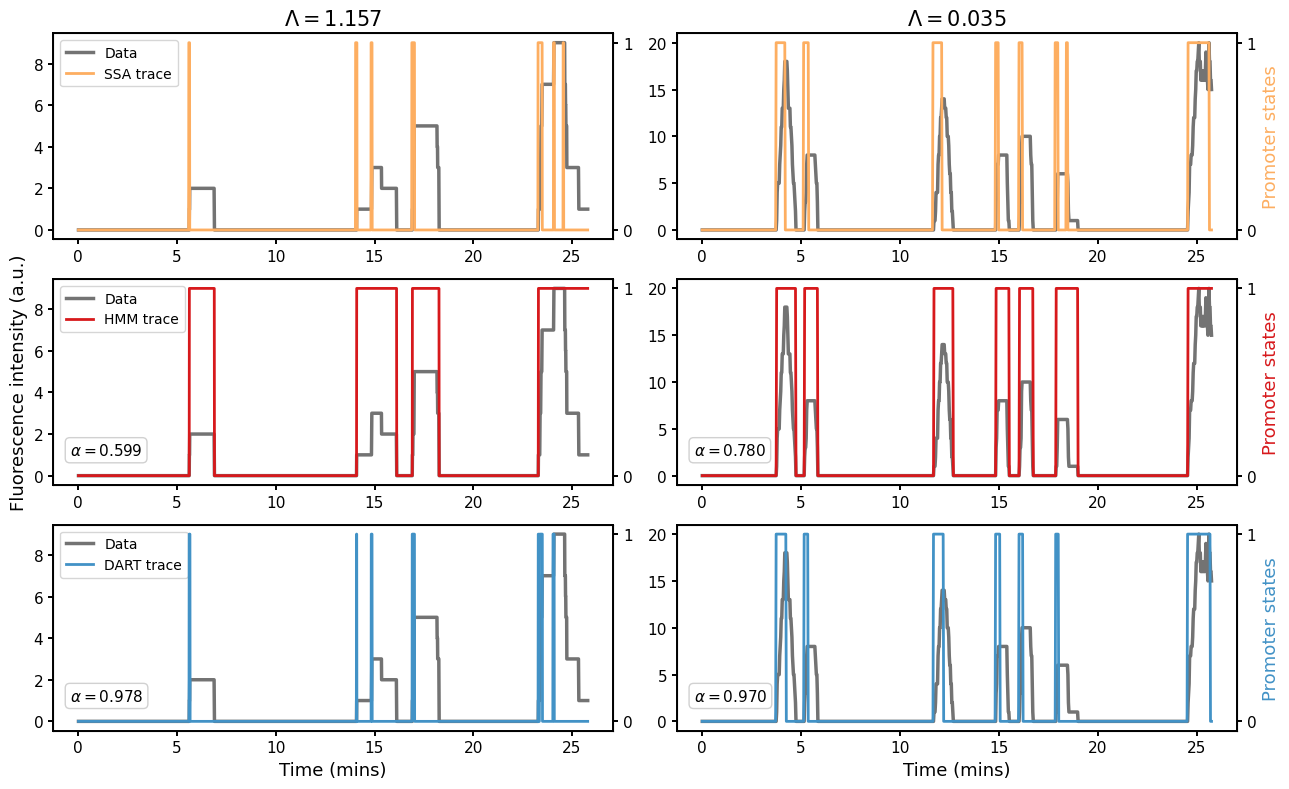

In [4]:
function plot_pair(ax, x, y_data, y_model; 
                   label_model="", 
                   color_model=nothing,
                   title="", xlabel="", ylabel_left="", ylabel_right="",
                   fs1=13, fs2=12, show_legend=true)

    # Default color map based on label
    default_colors = Dict(
        "SSA trace" => "#fdae61",
        "HMM trace" => "#d7191c",
        "DART trace" => "#4292c6"
    )
    color_model = isnothing(color_model) ? get(default_colors, label_model, "#fdae61") : color_model

    # Left axis: observed data
    line1, = ax.plot(x, y_data, color="#737373", lw=2.5, label="Data")

    # Right axis: model trace
    ax_twin = ax.twinx()
    line2, = ax_twin.plot(x, y_model, color=color_model, lw=2, label=label_model)

    # Combine legend only if needed
    if show_legend
        ax.legend([line1, line2], [line1.get_label(), line2.get_label()], loc="upper left", frameon=true, fontsize=10)
    end

    # Right y-axis formatting
    ax_twin.set_ylim(-0.05, 1.05)
    ax_twin.set_yticks([0.0, 1.0])
    
    # Tick font sizes
    ax.tick_params(axis="both", labelsize=fs2)
    ax_twin.tick_params(axis="both", labelsize=fs2)
    
    # Tick font sizes
    wd = 1.4
    ax.tick_params(axis="both", labelsize=11, width=wd)
    ax_twin.tick_params(axis="both", labelsize=11, width=wd)
    
    for spine in ax.spines.values()
        spine.set_linewidth(wd)
    end

    # Labels and title
    !isempty(title) && ax.set_title(title, fontsize=15)
    !isempty(xlabel) && ax.set_xlabel(xlabel, fontsize=fs1)
    !isempty(ylabel_left) && ax.set_ylabel(ylabel_left, fontsize=fs1)
    !isempty(ylabel_right) && ax_twin.set_ylabel(ylabel_right, fontsize=fs1, color=color_model)
end;

fig, axes = subplots(3, 2, figsize=(13, 8))

# --------- Left Column (ID = 265) ----------
id = 265
t_int = 3980:6740
x = genb_mtest[id].p[end] .* (1:length(t_int))
y1 = vcat(genb_mtest[id].syn...)[t_int]
y2 = vcat(genb_mtest[id].trace...)[t_int]
y3 = hmm_bad_trace[t_int]
#y3 = rn_data_hmm1[1].binar_trace[t_int]
y4 = dl_bad_trace[t_int]

plot_pair(axes[1,1], x, y1, y2, label_model="SSA trace", title=L"\Lambda=1.157")

plot_pair(axes[2,1], x, y1, y3, label_model="HMM trace", ylabel_left="Fluorescence intensity (a.u.)")
axes[2,1].text(0.03, 0.13, L"\alpha=0.599", transform=axes[2,1].transAxes,
               fontsize=11, ha="left", va="bottom",
               bbox=Dict("boxstyle"=>"round,pad=0.3", "facecolor"=>"white", "edgecolor"=>"#cccccc", "alpha"=>0.9))
plot_pair(axes[3,1], x, y1, y4, label_model="DART trace", xlabel="Time (mins)")
axes[3,1].text(0.03, 0.13, L"\alpha=0.978", transform=axes[3,1].transAxes,
               fontsize=11, ha="left", va="bottom",
               bbox=Dict("boxstyle"=>"round,pad=0.3", "facecolor"=>"white", "edgecolor"=>"#cccccc", "alpha"=>0.9))


# --------- Right Column (ID = 200) ----------
id = 200
t_int = 3100:4100
x = genb_mtest[id].p[end] .* (1:length(t_int))
y1 = vcat(genb_mtest[id].syn...)[t_int]
y2 = vcat(genb_mtest[id].trace...)[t_int]
y3 = hmm_good_trace[t_int]
#y3 = rn_data_hmm2[1].binar_trace[t_int]
y4 = dl_good_trace[t_int]

plot_pair(axes[1,2], x, y1, y2, label_model="SSA trace", title=L"\Lambda=0.035", ylabel_right="Promoter states", show_legend=false)
plot_pair(axes[2,2], x, y1, y3, label_model="HMM trace", ylabel_right="Promoter states", show_legend=false)
axes[2,2].text(0.03, 0.13, L"\alpha=0.780", transform=axes[2,2].transAxes,
               fontsize=11, ha="left", va="bottom",
               bbox=Dict("boxstyle"=>"round,pad=0.3", "facecolor"=>"white", "edgecolor"=>"#cccccc", "alpha"=>0.9))

plot_pair(axes[3,2], x, y1, y4, label_model="DART trace", ylabel_right="Promoter states", xlabel="Time (mins)", show_legend=false)
axes[3,2].text(0.03, 0.13, L"\alpha=0.970", transform=axes[3,2].transAxes,
               fontsize=11, ha="left", va="bottom",
               bbox=Dict("boxstyle"=>"round,pad=0.3", "facecolor"=>"white", "edgecolor"=>"#cccccc", "alpha"=>0.9))

tight_layout()
savefig("figs/hmmb_bad_good1.pdf", bbox_inches="tight")
